## Lab 3: Matrices and Operators

__Objective:__ Matrices play important roles in quantum mechanics, from observables to time evolution operators. 
First, we need to understand how to obtain the eigenvalues and eigenvectors of matrices, i.e., matrix diagonalization. 
Second, we need to understand how these bases transform, via unitary transformations. 
Catch: The choice of basis vectors is often convenient for computation. 
One should not think that the underlying physics depends on the particular choice.

__What will be covered?__
- Spin states
- Matrix diagonalization
- The Pauli matrices
- Measurement
- Basis change

In [1]:
import numpy as np
from qutip import Bloch, basis, Qobj, sigmap, sigmam, sigmax, sigmay, sigmaz, identity

### 1. Spin States

In [2]:
up = basis(2,0)
down = basis(2,1)
print(up,'\n')
print(down,'\n')

Quantum object: dims = [[2], [1]], shape = (2, 1), type = ket
Qobj data =
[[1.]
 [0.]] 

Quantum object: dims = [[2], [1]], shape = (2, 1), type = ket
Qobj data =
[[0.]
 [1.]] 



In [3]:
help(basis)

Help on function basis in module qutip.states:

basis(dimensions, n=None, offset=None)
    Generates the vector representation of a Fock state.
    
    Parameters
    ----------
    dimensions : int or list of ints
        Number of Fock states in Hilbert space.  If a list, then the resultant
        object will be a tensor product over spaces with those dimensions.
    
    n : int or list of ints, optional (default 0 for all dimensions)
        Integer corresponding to desired number state, defaults to 0 for all
        dimensions if omitted.  The shape must match ``dimensions``, e.g. if
        ``dimensions`` is a list, then ``n`` must either be omitted or a list
        of equal length.
    
    offset : int or list of ints, optional (default 0 for all dimensions)
        The lowest number state that is included in the finite number state
        representation of the state in the relevant dimension.
    
    Returns
    -------
    state : :class:`qutip.Qobj`
      Qobj represent

In [4]:
print(up.dag())

Quantum object: dims = [[1], [2]], shape = (1, 2), type = bra
Qobj data =
[[1. 0.]]


In [5]:
right = (up + down).unit()
left = (up - down).unit()
print(right,'\n')
print(left,'\n')

Quantum object: dims = [[2], [1]], shape = (2, 1), type = ket
Qobj data =
[[0.70710678]
 [0.70710678]] 

Quantum object: dims = [[2], [1]], shape = (2, 1), type = ket
Qobj data =
[[ 0.70710678]
 [-0.70710678]] 



For a two-level system, we can conveniently visualize the state of the system by plotting the state-vector or density matrix on the Bloch sphere. 

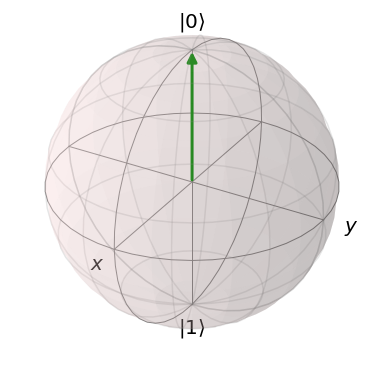

In [6]:
b = Bloch()
b.add_states(up)
b.render()

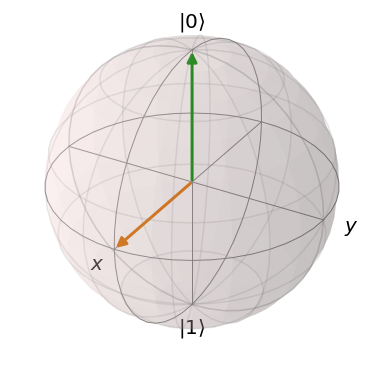

In [7]:
b.add_states(right)
b.render()

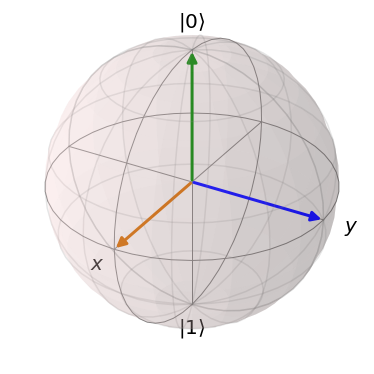

In [8]:
b.add_states((up + 1.j*down).unit())
b.render()

### 2. Matrix Diagonalization

The eigenvalue equation for a matrix $M$ is 

$$ M \vert \lambda \rangle = \lambda \vert \lambda \rangle, $$

where $\lambda$ and $\vert \lambda \rangle$ are eigenvalues and eigenvectors.

In [9]:
sx = Qobj([[0,1],[1,0]])
print(sx)
v, w = sx.eigenstates()
print('eigenvalues:', v, '\n')
print('eigenvectors: \n', w)

Quantum object: dims = [[2], [2]], shape = (2, 2), type = oper, isherm = True
Qobj data =
[[0. 1.]
 [1. 0.]]
eigenvalues: [-1.  1.] 

eigenvectors: 
 [Quantum object: dims = [[2], [1]], shape = (2, 1), type = ket
 Qobj data =
 [[ 0.70710678]
  [-0.70710678]]
 Quantum object: dims = [[2], [1]], shape = (2, 1), type = ket
 Qobj data =
 [[0.70710678]
  [0.70710678]]                                               ]


One can also use numpy.linalg.eigh() to diagonalize it. 

In [10]:
v,w = np.linalg.eigh(sx)
print('eigenvalues:', v, '\n')
print('eigenvectors: \n', w)

eigenvalues: [-1.  1.] 

eigenvectors: 
 [[-0.70710678+0.j  0.70710678+0.j]
 [ 0.70710678+0.j  0.70710678+0.j]]


In this case, it is ambiguous to identify the two eigenvectors. Are they row oriented, or column oriented? Make your own unambiguous example to understand. 

We gave the following example in the lecture

$$ \begin{pmatrix} 0 & -1 \\ 1 & 0 \end{pmatrix}
\begin{pmatrix} 1 \\ i \end{pmatrix} = -i \begin{pmatrix} 1 \\ i \end{pmatrix}.
$$

In [11]:
L = Qobj([[0,-1],[1,0]])
print(L, '\n')
print('eigenvalues:', L.eigenenergies())

Quantum object: dims = [[2], [2]], shape = (2, 2), type = oper, isherm = False
Qobj data =
[[ 0. -1.]
 [ 1.  0.]] 

eigenvalues: [0.00000000e+00+1.j 2.77555756e-17-1.j]


Note that the operator $L$ is not Hermitian, so the eigenvalues are not necessarily real. In NumPy, we use numpy.linalg.eig() rather than numpy.linalg.eigh() to diagonalize non-Hermitian matrices. 

### 3. The Pauli Matrices

The Pauli matrices are defined by 

$$ \sigma_x = \left ( 
    \begin{array}{cc}
    0 & 1 \\
    1 & 0    
    \end{array}
    \right ), \quad
    \sigma_y = \left ( 
    \begin{array}{cc}
    0 & -i \\
    i & 0    
    \end{array}
    \right ), \quad
    \sigma_z = \left ( 
    \begin{array}{cc}
    1 & 0 \\
    0 & -1    
    \end{array}
    \right ).
$$ 

They satisfy a set of rules we verify in Homework \#2, making them the simplest representation of the $SU(2)$ algebra

$$ \vec J \times \vec J = i \hbar \vec J, $$

which is equivalent to the angular momentum algebra in quantum mechanics. 


In [12]:
pauli_matrices = [sigmax(),sigmay(),sigmaz()]
i2 = identity(2)
for sigma in pauli_matrices:
    print(sigma, '\n')

Quantum object: dims = [[2], [2]], shape = (2, 2), type = oper, isherm = True
Qobj data =
[[0. 1.]
 [1. 0.]] 

Quantum object: dims = [[2], [2]], shape = (2, 2), type = oper, isherm = True
Qobj data =
[[0.+0.j 0.-1.j]
 [0.+1.j 0.+0.j]] 

Quantum object: dims = [[2], [2]], shape = (2, 2), type = oper, isherm = True
Qobj data =
[[ 1.  0.]
 [ 0. -1.]] 



Check $\sigma_x^2 = \sigma_y^2 = \sigma_z^2 = 1$. 

In [13]:
for sigma in pauli_matrices:
    print(sigma*sigma)
    print(np.allclose(sigma*sigma, i2),'\n')

Quantum object: dims = [[2], [2]], shape = (2, 2), type = oper, isherm = True
Qobj data =
[[1. 0.]
 [0. 1.]]
True 

Quantum object: dims = [[2], [2]], shape = (2, 2), type = oper, isherm = True
Qobj data =
[[1. 0.]
 [0. 1.]]
True 

Quantum object: dims = [[2], [2]], shape = (2, 2), type = oper, isherm = True
Qobj data =
[[1. 0.]
 [0. 1.]]
True 



In [14]:
help(np.allclose)

Help on function allclose in module numpy:

allclose(a, b, rtol=1e-05, atol=1e-08, equal_nan=False)
    Returns True if two arrays are element-wise equal within a tolerance.
    
    The tolerance values are positive, typically very small numbers.  The
    relative difference (`rtol` * abs(`b`)) and the absolute difference
    `atol` are added together to compare against the absolute difference
    between `a` and `b`.
    
    NaNs are treated as equal if they are in the same place and if
    ``equal_nan=True``.  Infs are treated as equal if they are in the same
    place and of the same sign in both arrays.
    
    Parameters
    ----------
    a, b : array_like
        Input arrays to compare.
    rtol : float
        The relative tolerance parameter (see Notes).
    atol : float
        The absolute tolerance parameter (see Notes).
    equal_nan : bool
        Whether to compare NaN's as equal.  If True, NaN's in `a` will be
        considered equal to NaN's in `b` in the output a

The Pauli matrices are Hermitian, i.e., their Hermitian conjugates are themselves. 

In [15]:
for sigma in pauli_matrices:
    print(sigma.conj().trans()) # Hermitian conjugate
    print(sigma.isherm,'\n') 

Quantum object: dims = [[2], [2]], shape = (2, 2), type = oper, isherm = True
Qobj data =
[[0. 1.]
 [1. 0.]]
True 

Quantum object: dims = [[2], [2]], shape = (2, 2), type = oper, isherm = True
Qobj data =
[[0.+0.j 0.-1.j]
 [0.+1.j 0.+0.j]]
True 

Quantum object: dims = [[2], [2]], shape = (2, 2), type = oper, isherm = True
Qobj data =
[[ 1.  0.]
 [ 0. -1.]]
True 



We can check the identity of the Pauli matrices, such as 

$$ \sigma_x \sigma_y = i \sigma_z. $$

Note the operator product is simply done by multiplying the two operators (with compatible shape).

In [16]:
print(sigmax()*sigmay(),'\n')
print(1.j*sigmaz(),'\n')
print(np.allclose(sigmax()*sigmay(), 1.j*sigmaz()))

Quantum object: dims = [[2], [2]], shape = (2, 2), type = oper, isherm = False
Qobj data =
[[0.+1.j 0.+0.j]
 [0.+0.j 0.-1.j]] 

Quantum object: dims = [[2], [2]], shape = (2, 2), type = oper, isherm = False
Qobj data =
[[0.+1.j 0.+0.j]
 [0.+0.j 0.-1.j]] 

True


For convenience, we often define two linear combinations of $\sigma_x$ and $\sigma_y$, because they have rather simple algebraic properties when applied to the spin states.

In [17]:
sigma_plus = (sigmax() + 1j * sigmay())/2.0
sigma_minus = (sigmax() - 1j * sigmay())/2.0
print(sigma_plus,'\n')
print(sigma_minus,'\n')

Quantum object: dims = [[2], [2]], shape = (2, 2), type = oper, isherm = False
Qobj data =
[[0. 1.]
 [0. 0.]] 

Quantum object: dims = [[2], [2]], shape = (2, 2), type = oper, isherm = False
Qobj data =
[[0. 0.]
 [1. 0.]] 



They are already defined in QuTiP, of course. 

In [18]:
print(sigmap(),'\n\n',sigmam(),'\n')

Quantum object: dims = [[2], [2]], shape = (2, 2), type = oper, isherm = False
Qobj data =
[[0. 1.]
 [0. 0.]] 

 Quantum object: dims = [[2], [2]], shape = (2, 2), type = oper, isherm = False
Qobj data =
[[0. 0.]
 [1. 0.]] 



In [19]:
print(np.allclose(sigmap()*down, up),'\n')
print(sigmap()*up,'\n')
print(np.allclose(sigmam()*up, down),'\n')
print(sigmam()*down,'\n')

True 

Quantum object: dims = [[2], [1]], shape = (2, 1), type = ket
Qobj data =
[[0.]
 [0.]] 

True 

Quantum object: dims = [[2], [1]], shape = (2, 1), type = ket
Qobj data =
[[0.]
 [0.]] 



### 4. Measurement

To perform a measurement, we can use the `measure` function, which is a dispatch method that provides measurement results handling both observable style measurements and projector style measurements (POVMs and PVMs).

In [20]:
from qutip.measurement import measure

psi_in = (basis(2,0) + basis(2,1))/np.sqrt(2)

for _ in range(10):
    sz, psi_out = measure(psi_in, sigmaz())
    print(sz)


-1.0
-1.0
1.0
-1.0
-1.0
1.0
1.0
1.0
-1.0
-1.0


In reality, we cannot keep the original copy psi_in. After the measurement, the state collapses according to the measurement outcome. So we should simulate with `sz, psi = measure(psi, sigmaz())`.

Likewise, we can use the `measurement_statistics` function to get the measurement statistics of a state, handling both
observable style measurements and projector style measurements (POVMs and PVMs).

In [21]:
from qutip.measurement import measurement_statistics

measurement_statistics(psi_in, sigmaz())


(array([-1.,  1.]),
 array([Quantum object: dims = [[2], [1]], shape = (2, 1), type = ket
        Qobj data =
        [[0.]
         [1.]]                                                       ,
        Quantum object: dims = [[2], [1]], shape = (2, 1), type = ket
        Qobj data =
        [[1.]
         [0.]]                                                       ],
       dtype=object),
 [0.4999999999999999, 0.4999999999999999])

### 5. Basis Change

A change of basis matrix maps an input basis to an output basis. Let’s call the input basis $B$ with the basis vectors $\vert i \rangle$
and $\vert j \rangle$, and the output basis $B'$ with the basis vectors $\vert i' \rangle$ and $\vert j' \rangle$. 
We group the two basis vectors into a matrix in each case

$$ B = [\vert i \rangle, \vert j \rangle], \quad B' = [\vert i' \rangle, \vert j' \rangle]. $$

With the help of the Dirac notation we easily have

$$ \vert i' \rangle = \vert i \rangle \langle i \vert i' \rangle + \vert j \rangle \langle j \vert i' \rangle, $$
$$ \vert j' \rangle = \vert i \rangle \langle i \vert j' \rangle + \vert j \rangle \langle j \vert j' \rangle, $$

From the equation of the change of basis, we seek

$$ [\vert i' \rangle, \vert j' \rangle] = [\vert i \rangle, \vert j \rangle] C, \quad \text{or}\ 
B' = B C. $$

We can read from above 

$$ C = \begin{pmatrix}
   \langle i \vert i' \rangle & \langle i \vert j' \rangle \\
   \langle j \vert i' \rangle & \langle j \vert j' \rangle 
\end{pmatrix} 
$$

To go backward, we have 

$$ [\vert i \rangle, \vert j \rangle] = [\vert i' \rangle, \vert j' \rangle] C^{-1}. $$

---

## Lab 3 Exercises

Student Name: _________________________________

Student ID: ___________________________________   

Date: _________________________________________

### E1. State Transformation

Now consider a generic quantum state on the Bloch sphere

$$ \left \vert \psi \right \rangle = \alpha \left \vert 0 \right \rangle + \beta \left \vert 1 \right \rangle = \left ( 
    \begin{array}{c}
    \alpha \\
    \beta
    \end{array} 
    \right ), \quad \alpha, \beta \in \mathbb{C}$$ 

normalized by (the probabilistic interpretation)

$$ \langle \psi \vert \psi \rangle = |\alpha|^2 + |\beta|^2 = 1. $$

We can alternatively write down the state in the $\sigma_x$ basis, 

$$ \left \vert + \right \rangle = \frac1{\sqrt2} \left ( 
    \begin{array}{c}
    1 \\
    1
    \end{array} 
    \right ), \ 
   \left \vert - \right \rangle = \frac1{\sqrt2} \left ( 
    \begin{array}{c}
    1 \\
    -1
    \end{array} 
    \right ).
$$

Assume the state is 

$$ \left \vert \psi \right \rangle = \alpha' \left \vert + \right \rangle + \beta' \left \vert - \right \rangle, 
\quad \alpha, \beta \in \mathbb{C} 
$$ 

What matrix transforms $(\alpha, \beta)$ to $(\alpha', \beta')$? What are the matrix representations for $\sigma_x$, $\sigma_y$, $\sigma_z$ in the new basis? Compare the the numpy realization with the derivation using the Dirac notation.

### E2. Two Qubits

We will discuss how to describe states and measurements in multi-qubit systems in the coming lecture. Let us do some warm-up exercises here. Assume we use four column vectors 

$$ \vert 00 \rangle = \left ( \begin{array}{c} 1 \\ 0 
\\ 0 \\ 0 \end{array} \right ), \ 
   \vert 01 \rangle = \left ( \begin{array}{c} 0 \\ 1 
\\ 0 \\ 0 \end{array} \right ), \ 
   \vert 10 \rangle = \left ( \begin{array}{c} 0 \\ 0 
\\ 1 \\ 0 \end{array} \right ), \ 
   \vert 11 \rangle = \left ( \begin{array}{c} 0 \\ 0 
\\ 0 \\ 1 \end{array} \right ). \ 
$$

to represent two-bit states.
Construct $\sigma_{1x}$, $\sigma_{1y}$, $\sigma_{1z}$, now $4 \times 4$ matrices, that operates only on the first qubit. Likewise, construct $\sigma_{2x}$, $\sigma_{2y}$, $\sigma_{2z}$ that operates only on the second qubit. 

Use your result to calculate 

$$ \vec \sigma_1 \cdot \vec \sigma_2 = \sigma_{1x} \sigma_{2x} + \sigma_{1y} \sigma_{2y} + \sigma_{1z} \sigma_{2z}. $$

Diagonalize $\vec \sigma_1 \cdot \vec \sigma_2$ and list the four eigenvectors and their corresponding eigenvalues. 